In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
# Construct the path to the dataset in your Google Drive
dataset_path = '/content/drive/My Drive/Agriculture/final_ds.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(dataset_path)

# Display the first few rows of the DataFrame
display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
df.shape

(2200, 8)

In [ ]:
# Calculate the sum of null values for each column
null_counts = df.isnull().sum()

# Display the sum of null values for each column
print("Null values per column:")
print(null_counts)

# Calculate the total sum of null values in the DataFrame
total_null_count = null_counts.sum()

# Display the total sum of null values
print(f"\nTotal number of empty values in the DataFrame: {total_null_count}")

Null values per column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Total number of empty values in the DataFrame: 0


In [ ]:
# Install essential libraries
!pip install shap lightgbm matplotlib seaborn scikit-learn pandas numpy --quiet

In [ ]:

# Import standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

In [ ]:
# ==========================================================
# 🎨 Custom Journal-Grade Theme
# ==========================================================
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.9)
sns.set_style('whitegrid')

# Define AgriTech Gradient Palette
agri_palette = {
    'nutrients': ['#5A3E1B', '#A47148', '#DDA15E'],
    'environment': ['#004E64', '#007A8E', '#00A5CF'],
    'soil': ['#556B2F', '#A7C957'],
    'indices': ['#3C096C', '#7B2CBF', '#9D4EDD'],
    'results': ['#343A40', '#F9C74F']
}

# Register a cohesive color palette for Seaborn
flat_palette = sum(agri_palette.values(), [])
sns.set_palette(flat_palette)

print("✅ Environment ready — libraries loaded and custom AgriTech theme applied.")

✅ Environment ready — libraries loaded and custom AgriTech theme applied.


In [ ]:
# Basic info
print("✅ Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

✅ Dataset loaded successfully!
Shape: (2200, 8)

Data Types:
N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [ ]:
# Quick null check
print("\nMissing Values per Column:")
print(df.isnull().sum())


Missing Values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [ ]:
summary_stats = df.describe().T
display(summary_stats)

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


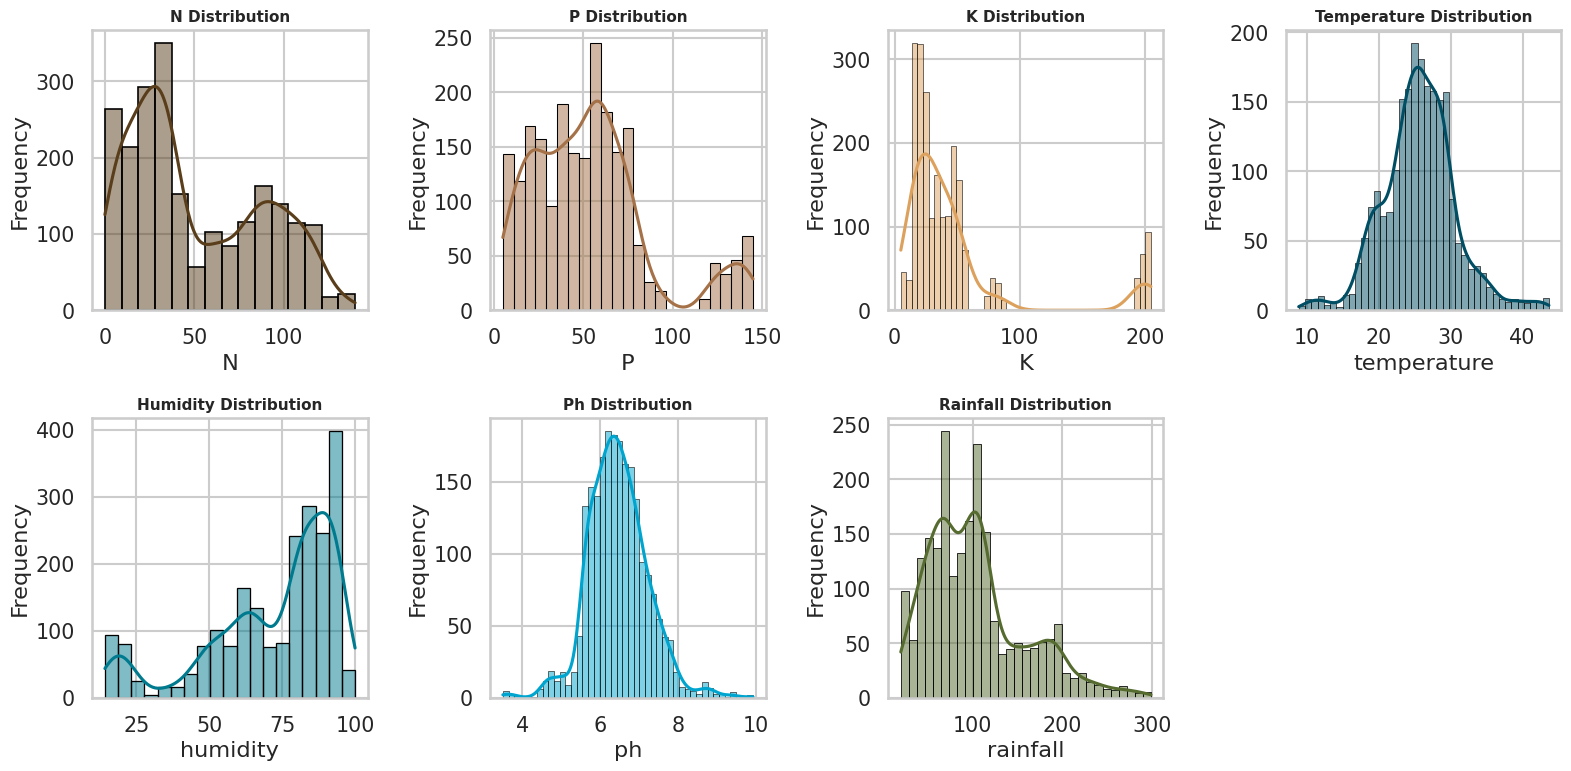

In [ ]:
# ==========================================================
# 📈 Visual Summary — Feature Distributions (N, P, K, temperature, humidity, ph, rainfall)
# ==========================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
features = ['N','P','K','temperature','humidity','ph','rainfall']

for i, feat in enumerate(features):
    sns.histplot(df[feat], kde=True, ax=axes[i], color=flat_palette[i % len(flat_palette)], edgecolor='black')
    axes[i].set_title(f"{feat.capitalize()} Distribution", fontsize=11, fontweight='bold')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')  # last empty subplot
plt.tight_layout()
plt.show()

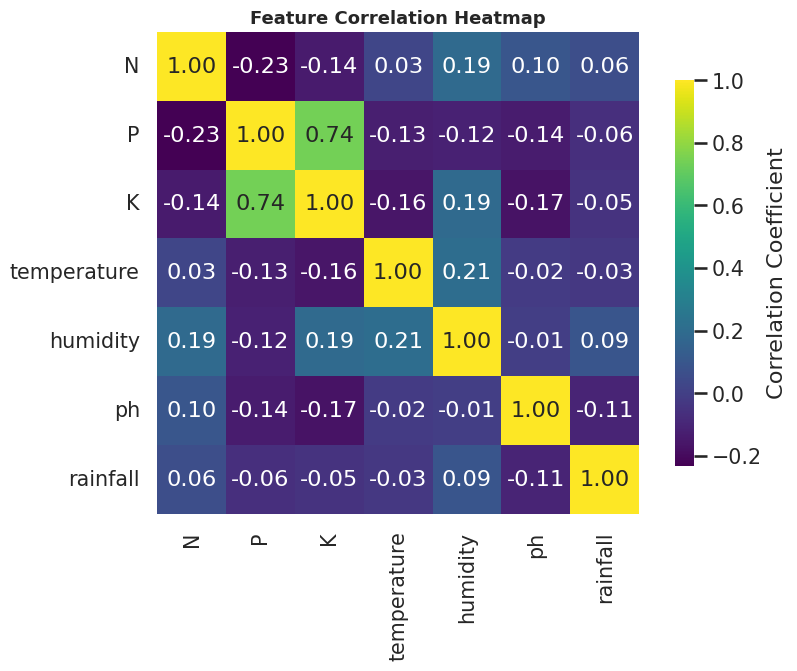

In [ ]:
# ==========================================================
# 🔍 Cell 3 — Correlation & Crop Distribution Analysis
# ==========================================================

# 1️⃣ Correlation Matrix Heatmap
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap='viridis', square=True,
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'}
)
plt.title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipython-input-3998761823.py:3: UserWarning: The palette list has more values (13) than needed (7), which may not be intended.
  sns.boxplot(data=df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']],


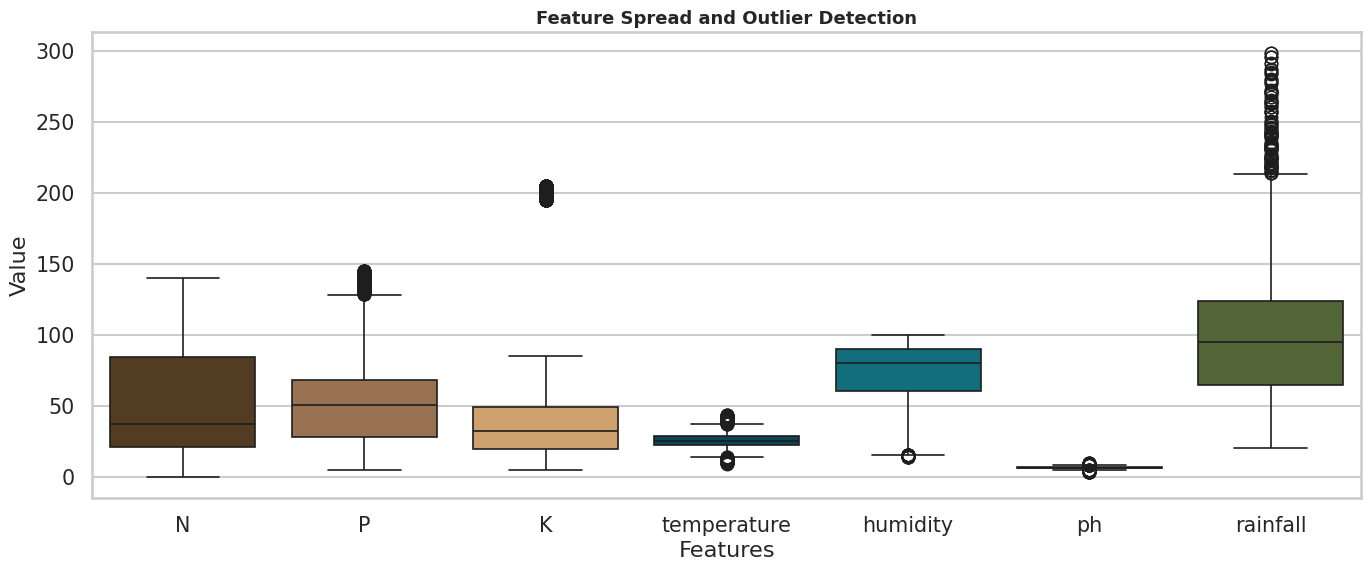

In [ ]:
# 2️⃣ Boxplots — Outlier & Spread Detection
plt.figure(figsize=(14, 6))
sns.boxplot(data=df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']],
            palette=flat_palette, linewidth=1.2)
plt.title("Feature Spread and Outlier Detection", fontsize=13, fontweight='bold')
plt.xlabel("Features")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

Rainfall capped between 21.90 and 267.99

Scaled Feature Ranges:
       N    P    K  temperature  humidity   ph  rainfall
min  0.0  0.0  0.0          0.0       0.0  0.0       0.0
max  1.0  1.0  1.0          1.0       1.0  1.0       1.0


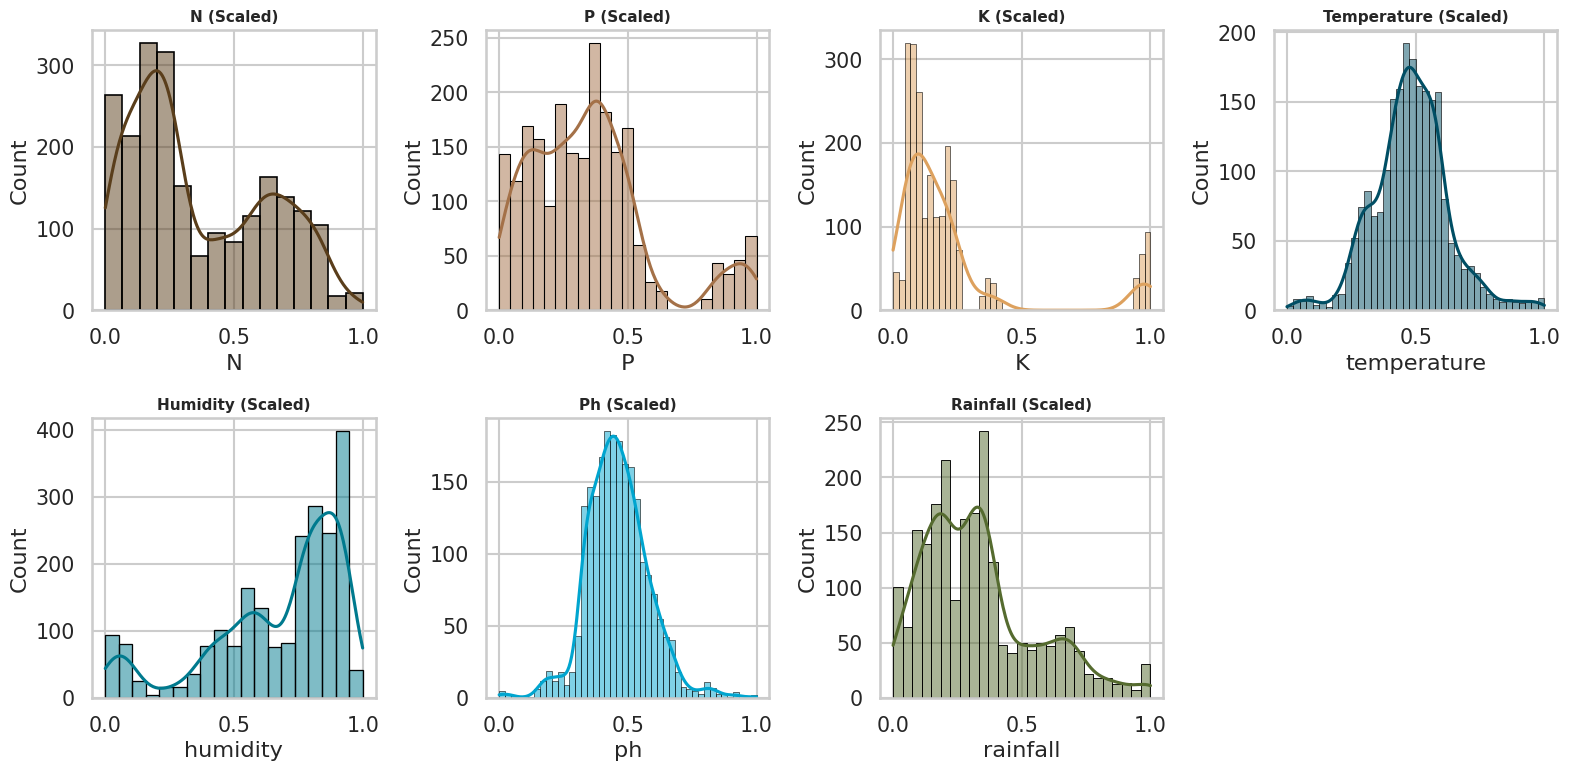

In [ ]:
# ==========================================================
# 🧹 Cell 4a — Light Outlier Capping + Normalization
# ==========================================================

# Copy original to preserve raw data
df_clean = df.copy()

# 1️⃣ Light winsorization for rainfall (cap extremes)
lower_cap = df_clean['rainfall'].quantile(0.01)
upper_cap = df_clean['rainfall'].quantile(0.99)
df_clean['rainfall'] = np.clip(df_clean['rainfall'], lower_cap, upper_cap)

print(f"Rainfall capped between {lower_cap:.2f} and {upper_cap:.2f}")

# 2️⃣ Min–Max normalization for numeric features
features_to_scale = ['N','P','K','temperature','humidity','ph','rainfall']
scaler = MinMaxScaler()
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

# 3️⃣ Verify range after scaling
print("\nScaled Feature Ranges:")
print(df_clean[features_to_scale].agg(['min','max']))

# 4️⃣ Quick check histogram after scaling
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_scale):
    sns.histplot(df_clean[feat], kde=True, ax=axes[i],
                 color=flat_palette[i % len(flat_palette)], edgecolor='black')
    axes[i].set_title(f"{feat.capitalize()} (Scaled)", fontsize=11, fontweight='bold')

axes[-1].axis('off')
plt.tight_layout()
plt.show()


,N,P,K,temperature,humidity,NBI,ERS
0,0.642857,0.264286,0.190,0.345886,0.790267,0.743883,0.544919
1,0.607143,0.378571,0.180,0.371445,0.770633,0.778140,0.557634
2,0.428571,0.357143,0.195,0.406854,0.793977,0.883768,0.592381
3,0.528571,0.214286,0.175,0.506901,0.768751,0.789152,0.650628
4,0.557143,0.264286,0.185,0.324378,0.785626,0.795677,0.526152


,NBI,ERS
count,2200.000000,2200.000000
mean,0.722100,0.569856
std,0.213959,0.181854
min,0.000000,0.000000
25%,0.645493,0.509838
50%,0.791803,0.606997
75%,0.860930,0.675384
max,1.000000,1.000000


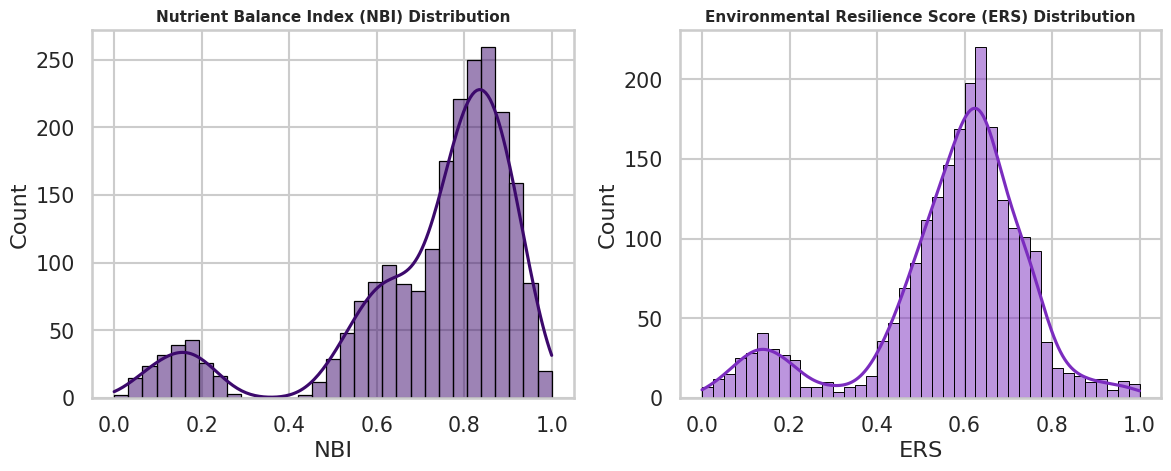

In [ ]:
# ==========================================================
# 🧮 Cell 5 — Compute Custom Indices (NBI & ERS)
# ==========================================================

# Copy dataset for derived features
df_features = df_clean.copy()

# ----------------------------------------------------------
# 1️⃣ Nutrient Balance Index (NBI)
# ----------------------------------------------------------
# Define dataset median values as optimal targets
N_opt, P_opt, K_opt = df_features[['N','P','K']].median()

# Calculate deviation from optimal ratios
df_features['NBI'] = 1 - (abs(df_features['N'] - N_opt) +
                          abs(df_features['P'] - P_opt) +
                          abs(df_features['K'] - K_opt)) / 3

# Normalize NBI to [0,1]
df_features['NBI'] = MinMaxScaler().fit_transform(df_features[['NBI']])

# ----------------------------------------------------------
# 2️⃣ Environmental Resilience Score (ERS)
# ----------------------------------------------------------
# Combine normalized temperature & humidity
df_features['ERS'] = (df_features['temperature'] * df_features['humidity']) ** 0.5

# Normalize ERS to [0,1]
df_features['ERS'] = MinMaxScaler().fit_transform(df_features[['ERS']])

# ----------------------------------------------------------
# Display sample and describe new features
display(df_features[['N','P','K','temperature','humidity','NBI','ERS']].head())
display(df_features[['NBI','ERS']].describe())

# ----------------------------------------------------------
# 📊 Visualize Distributions of Derived Features
# ----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_features['NBI'], kde=True, color=agri_palette['indices'][0], ax=axes[0], edgecolor='black')
axes[0].set_title("Nutrient Balance Index (NBI) Distribution", fontsize=11, fontweight='bold')

sns.histplot(df_features['ERS'], kde=True, color=agri_palette['indices'][1], ax=axes[1], edgecolor='black')
axes[1].set_title("Environmental Resilience Score (ERS) Distribution", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================
# 🔗 Cell 5a — Crop Pair Generator Setup
# ==========================================================
from itertools import combinations
import itertools

# Select essential columns for pair generation
cols = ['label', 'N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'NBI', 'ERS']
df_pairs_base = df_features[cols].copy()

# ----------------------------------------------------------
# 1️⃣ Generate all unique crop pairs (i,j) — across the dataset
# ----------------------------------------------------------
crop_pairs = list(combinations(df_pairs_base.index, 2))  # all unique pairs
print(f"✅ Generated {len(crop_pairs):,} unique crop combinations for analysis.")

# ----------------------------------------------------------
# 2️⃣ Build pairwise DataFrame (for efficient vector operations)
# ----------------------------------------------------------
pairs_data = []

for i, j in crop_pairs:
    a, b = df_pairs_base.loc[i], df_pairs_base.loc[j]
    pairs_data.append({
        'Crop_A': a['label'],
        'Crop_B': b['label'],
        # Nutrients
        'N_A': a['N'], 'P_A': a['P'], 'K_A': a['K'],
        'N_B': b['N'], 'P_B': b['P'], 'K_B': b['K'],
        # Environment
        'temp_A': a['temperature'], 'temp_B': b['temperature'],
        'hum_A': a['humidity'], 'hum_B': b['humidity'],
        'ph_A': a['ph'], 'ph_B': b['ph'],
        'rain_A': a['rainfall'], 'rain_B': b['rainfall'],
        # Derived Indices
        'NBI_A': a['NBI'], 'NBI_B': b['NBI'],
        'ERS_A': a['ERS'], 'ERS_B': b['ERS']
    })

df_pairs = pd.DataFrame(pairs_data)

# ----------------------------------------------------------
# 3️⃣ Compute quick sanity check
# ----------------------------------------------------------
display(df_pairs.head())
print(f"✅ Pairwise DataFrame ready with shape: {df_pairs.shape}")


✅ Generated 2,418,900 unique crop combinations for analysis.


,Crop_A,Crop_B,N_A,P_A,K_A,N_B,P_B,K_B,temp_A,temp_B,hum_A,hum_B,ph_A,ph_B,rain_A,rain_B,NBI_A,NBI_B,ERS_A,ERS_B
0,rice,rice,0.642857,0.264286,0.19,0.607143,0.378571,0.180,0.345886,0.371445,0.790267,0.770633,0.466264,0.549480,0.735639,0.832028,0.743883,0.778140,0.544919,0.557634
1,rice,rice,0.642857,0.264286,0.19,0.428571,0.357143,0.195,0.345886,0.406854,0.790267,0.793977,0.466264,0.674219,0.735639,0.983635,0.743883,0.883768,0.544919,0.592381
2,rice,rice,0.642857,0.264286,0.19,0.528571,0.214286,0.175,0.345886,0.506901,0.790267,0.768751,0.466264,0.540508,0.735639,0.897892,0.743883,0.789152,0.544919,0.650628
3,rice,rice,0.642857,0.264286,0.19,0.557143,0.264286,0.185,0.345886,0.324378,0.790267,0.785626,0.466264,0.641291,0.735639,0.978568,0.743883,0.795677,0.544919,0.526152
4,rice,rice,0.642857,0.264286,0.19,0.492857,0.228571,0.185,0.345886,0.408392,0.790267,0.806218,0.466264,0.554979,0.735639,0.931177,0.743883,0.811990,0.544919,0.598057


✅ Pairwise DataFrame ready with shape: (2418900, 20)


,Crop_A,Crop_B,NutComp,CP,CCI
0,rice,rice,0.863306,0.086235,0.936103
1,rice,rice,0.793673,0.213340,0.810022
2,rice,rice,0.851359,0.186623,0.861373
3,rice,rice,0.946780,0.155889,0.901493
4,rice,rice,0.868402,0.119923,0.923638


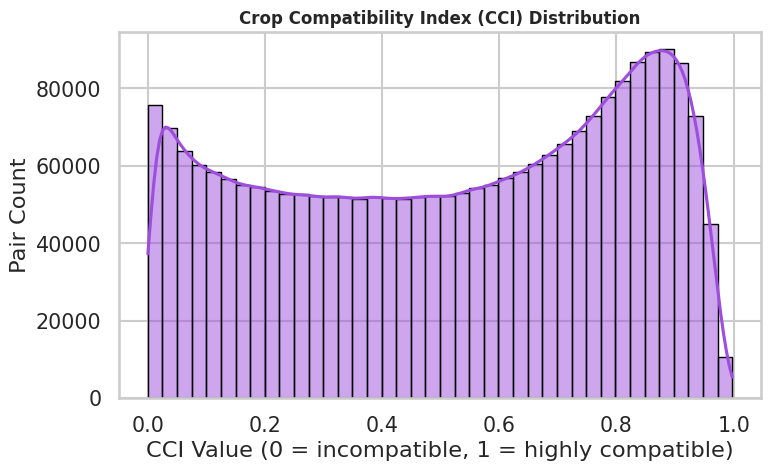

✅ CCI computation complete — ready for ranking and model analysis.


In [ ]:
# ==========================================================
# 🌾 Cell 6 — Compute Nutrient Complementarity + Conflict Penalty + CCI
# ==========================================================

# For speed, operate on a smaller representative subset first (optional)
# df_pairs_sub = df_pairs.sample(100000, random_state=42)
df_pairs_sub = df_pairs  # full if GPU is active

# ----------------------------------------------------------
# 1️⃣ Nutrient Complementarity (NutComp)
#    Measures nutrient synergy between Crop A and Crop B
# ----------------------------------------------------------
eps = 1e-6
df_pairs_sub['NutComp'] = (
    (np.minimum(df_pairs_sub['N_A'], df_pairs_sub['N_B']) / (np.maximum(df_pairs_sub['N_A'], df_pairs_sub['N_B']) + eps)) +
    (np.minimum(df_pairs_sub['P_A'], df_pairs_sub['P_B']) / (np.maximum(df_pairs_sub['P_A'], df_pairs_sub['P_B']) + eps)) +
    (np.minimum(df_pairs_sub['K_A'], df_pairs_sub['K_B']) / (np.maximum(df_pairs_sub['K_A'], df_pairs_sub['K_B']) + eps))
) / 3

# ----------------------------------------------------------
# 2️⃣ Conflict Penalty (CP)
#    Penalizes pH or temperature mismatch
# ----------------------------------------------------------
def conflict_penalty(row):
    ph_diff = abs(row['ph_A'] - row['ph_B'])
    temp_diff = abs(row['temp_A'] - row['temp_B'])
    return 0.5 * ph_diff + 0.5 * temp_diff

df_pairs_sub['CP'] = df_pairs_sub.apply(conflict_penalty, axis=1)

# Normalize CP to [0,1]
df_pairs_sub['CP'] = MinMaxScaler().fit_transform(df_pairs_sub[['CP']])

# ----------------------------------------------------------
# 3️⃣ Compute Crop Compatibility Index (CCI)
# ----------------------------------------------------------
# Tunable weights (can optimize later)
w1, w2, w3 = 0.35, 0.35, 0.30

df_pairs_sub['NBI_avg'] = (df_pairs_sub['NBI_A'] + df_pairs_sub['NBI_B']) / 2
df_pairs_sub['ERS_avg'] = (df_pairs_sub['ERS_A'] + df_pairs_sub['ERS_B']) / 2

linear_score = (w1 * df_pairs_sub['NBI_avg'] +
                w2 * df_pairs_sub['ERS_avg'] +
                w3 * df_pairs_sub['NutComp'] -
                df_pairs_sub['CP'])

# Logistic transform to bound between 0–1
df_pairs_sub['CCI'] = 1 / (1 + np.exp(-10 * (linear_score - linear_score.mean())))

# ----------------------------------------------------------
# 4️⃣ Display and visualize
# ----------------------------------------------------------
display(df_pairs_sub[['Crop_A','Crop_B','NutComp','CP','CCI']].head())

plt.figure(figsize=(8,5))
sns.histplot(df_pairs_sub['CCI'], bins=40, kde=True,
             color=agri_palette['indices'][2], edgecolor='black')
plt.title("Crop Compatibility Index (CCI) Distribution", fontsize=12, fontweight='bold')
plt.xlabel("CCI Value (0 = incompatible, 1 = highly compatible)")
plt.ylabel("Pair Count")
plt.tight_layout()
plt.show()

print("✅ CCI computation complete — ready for ranking and model analysis.")


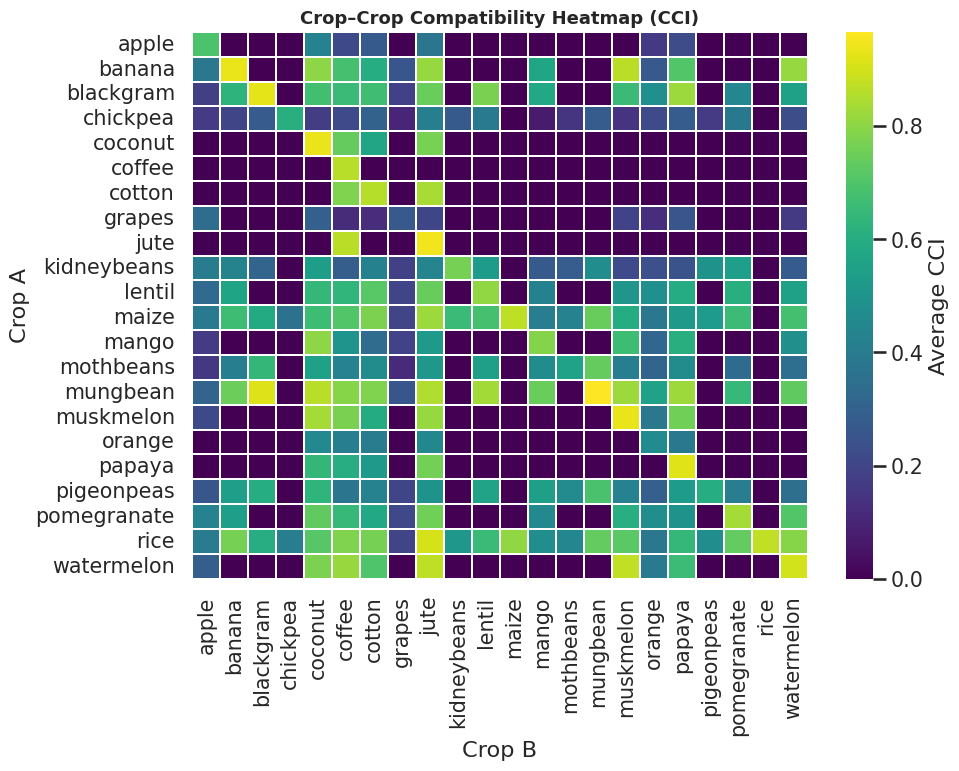

,Crop_A,Crop_B,CCI
0,papaya,papaya,0.997527
1,mungbean,mungbean,0.994217
2,coconut,coconut,0.992458
3,pigeonpeas,pigeonpeas,0.990533
4,mungbean,blackgram,0.990188
5,mungbean,lentil,0.989706
6,mungbean,papaya,0.989094
7,rice,jute,0.988969
8,mothbeans,mungbean,0.988840
9,orange,orange,0.988687


/tmp/ipython-input-130089226.py:48: UserWarning: 
The palette list has fewer values (3) than needed (8) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


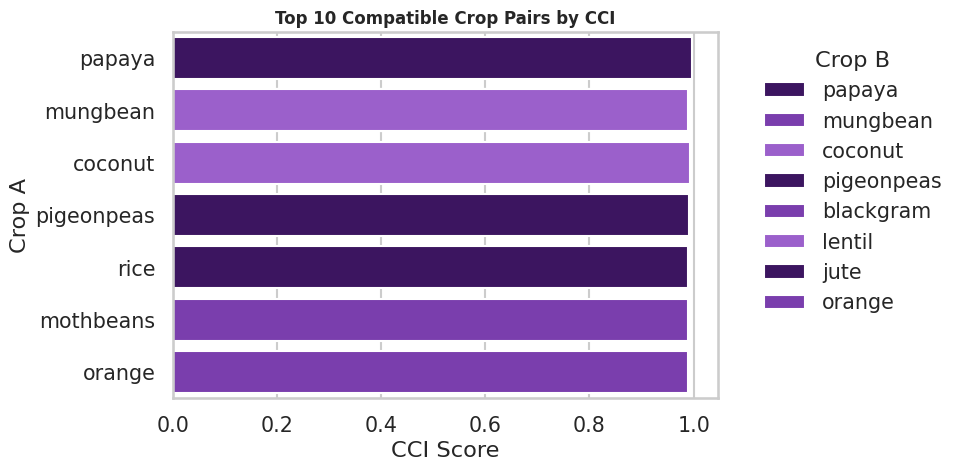

✅ Compatibility visualization and ranking completed.


In [ ]:
# ==========================================================
# 🌿 Cell 7 — Compatibility Heatmap + Top Pair Rankings
# ==========================================================

# ----------------------------------------------------------
# 1️⃣ Aggregate mean CCI per (Crop_A, Crop_B)
# ----------------------------------------------------------
compat_matrix = (
    df_pairs_sub.groupby(['Crop_A','Crop_B'])['CCI']
    .mean()
    .unstack()
    .fillna(0)
)

# ----------------------------------------------------------
# 2️⃣ Plot Compatibility Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(
    compat_matrix,
    cmap='viridis',
    annot=False,
    cbar_kws={'label': 'Average CCI'},
    linewidths=0.3
)
plt.title("Crop–Crop Compatibility Heatmap (CCI)", fontsize=13, fontweight='bold')
plt.xlabel("Crop B")
plt.ylabel("Crop A")
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 3️⃣ Extract Top-Compatible Crop Pairs
# ----------------------------------------------------------
top_pairs = (
    df_pairs_sub[['Crop_A','Crop_B','CCI']]
    .sort_values(by='CCI', ascending=False)
    .drop_duplicates(subset=['Crop_A','Crop_B'])
    .head(20)
    .reset_index(drop=True)
)
display(top_pairs)

# ----------------------------------------------------------
# 4️⃣ Quick Insight Visualization (Top 10 Bar Plot)
# ----------------------------------------------------------
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_pairs.head(10),
    x='CCI', y='Crop_A',
    hue='Crop_B',
    dodge=False,
    palette=agri_palette['indices']
)
plt.title("Top 10 Compatible Crop Pairs by CCI", fontsize=12, fontweight='bold')
plt.xlabel("CCI Score")
plt.ylabel("Crop A")
plt.legend(title="Crop B", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("✅ Compatibility visualization and ranking completed.")


In [ ]:
# ========== Cell 8a: Train/Test split & KNN ==========
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

features = ['NBI_avg','ERS_avg','NutComp','CP']
X = df_pairs_sub[features]
y = df_pairs_sub['CCI']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN baseline
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)

knn_r2 = r2_score(y_test, knn_preds)
knn_rmse = np.sqrt(mean_squared_error(y_test, knn_preds))

print(f"KNN -> R2: {knn_r2:.4f}, RMSE: {knn_rmse:.4f}")
# Save results to dict for aggregation later
baseline_results = [{'Model':'KNN', 'R2':knn_r2, 'RMSE':knn_rmse}]


KNN -> R2: 0.9997, RMSE: 0.0055


In [ ]:
# ========== Cell 8b-Lite: RandomForest & LinearRegression (sampled) ==========
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# ✅ Use a sample to prevent OOM crash
sample_size = 150000   # adjust to 100k–200k for your GPU memory
df_sample = df_pairs_sub.sample(sample_size, random_state=42)

X_sample = df_sample[features]
y_sample = df_sample['CCI']

X_train, X_test, y_train, y_test = train_test_split(X_sample, y_sample, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=80, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_r2 = r2_score(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
baseline_results.append({'Model':'RandomForest', 'R2':rf_r2, 'RMSE':rf_rmse})

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_r2 = r2_score(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
baseline_results.append({'Model':'LinearRegression', 'R2':lr_r2, 'RMSE':lr_rmse})

# Show results
results_df = pd.DataFrame(baseline_results)
display(results_df)

print(f"✅ Used {sample_size:,} samples for model training — safe & reproducible.")


,Model,R2,RMSE
0,KNN,0.999653,0.005468
1,RandomForest,0.995550,0.019591
2,LinearRegression,0.936664,0.073912


✅ Used 150,000 samples for model training — safe & reproducible.


In [ ]:
# ==========================================================
# 💾 Cell 8-Safe — Save Essential DataFrames to Drive (Optimized)
# ==========================================================

save_path = '/content/drive/My Drive/Agriculture/AgriCompatNet_Saves/'

import os, joblib
os.makedirs(save_path, exist_ok=True)

# ✅ Save lighter, essential data only
df_features.to_csv(save_path + 'df_features.csv', index=False)
df_sample.to_csv(save_path + 'df_pairs_sample.csv', index=False)   # smaller subset
results_df.to_csv(save_path + 'baseline_results.csv', index=False)

# ✅ Save trained models
joblib.dump(knn, save_path + 'knn_model.pkl')
joblib.dump(rf, save_path + 'rf_model.pkl')
joblib.dump(lr, save_path + 'lr_model.pkl')

print("✅ All key dataframes and models saved safely in:")
print(save_path)


✅ All key dataframes and models saved safely in:
/content/drive/My Drive/Agriculture/AgriCompatNet_Saves/


,Removed Feature,R²
0,NBI_avg,0.929115
1,ERS_avg,0.932987
2,NutComp,0.928231
3,CP,0.520244


/tmp/ipython-input-375130564.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-375130564.py:28: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/tmp/ipython-input-375130564.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-375130564.py:36: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


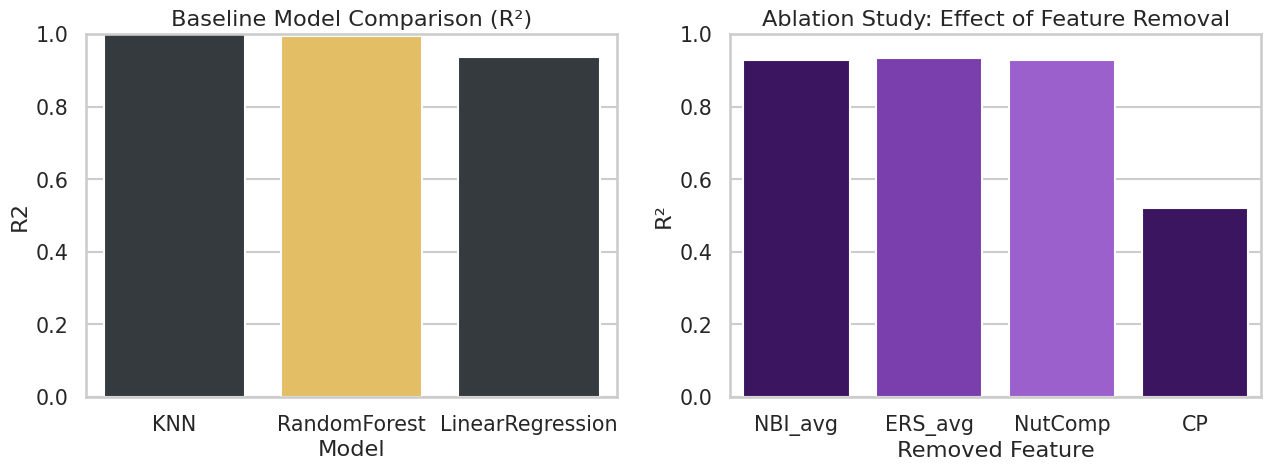

✅ Ablation study completed safely using sampled data.


In [ ]:
# ========== Cell 8c (Optimized): Ablation Study & Plots ==========
from sklearn.ensemble import RandomForestRegressor

ablation_results = []

# Use the same sample as in 8b-Lite
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

for feature_to_remove in features:
    subset = [f for f in features if f != feature_to_remove]
    model = RandomForestRegressor(
        n_estimators=70, max_depth=12, random_state=42, n_jobs=-1
    )
    model.fit(X_train_s[subset], y_train_s)
    preds = model.predict(X_test_s[subset])
    r2 = r2_score(y_test_s, preds)
    ablation_results.append({'Removed Feature': feature_to_remove, 'R²': r2})

ablation_df = pd.DataFrame(ablation_results)
display(ablation_df)

# ===================== Visualization =====================
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# Baseline Model Comparison
sns.barplot(
    data=results_df, x='Model', y='R2',
    palette=agri_palette['results'], ax=ax[0]
)
ax[0].set_title("Baseline Model Comparison (R²)")
ax[0].set_ylim(0, 1)

# Ablation Study
sns.barplot(
    data=ablation_df, x='Removed Feature', y='R²',
    palette=agri_palette['indices'], ax=ax[1]
)
ax[1].set_title("Ablation Study: Effect of Feature Removal")
ax[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("✅ Ablation study completed safely using sampled data.")


In [ ]:
# ==========================================================
# 🧩 Cell 9a — SHAP Setup and Value Computation (RAM-safe)
# ==========================================================
import shap
import random

# Use the already trained RandomForest model (rf) and X_sample subset
explainer_sample = X_sample.sample(5000, random_state=42)  # reduce to 5k for speed/memory

# Create SHAP TreeExplainer (optimized for tree models)
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(explainer_sample)

print("✅ SHAP values computed successfully on 5k sample (memory-safe).")


✅ SHAP values computed successfully on 5k sample (memory-safe).


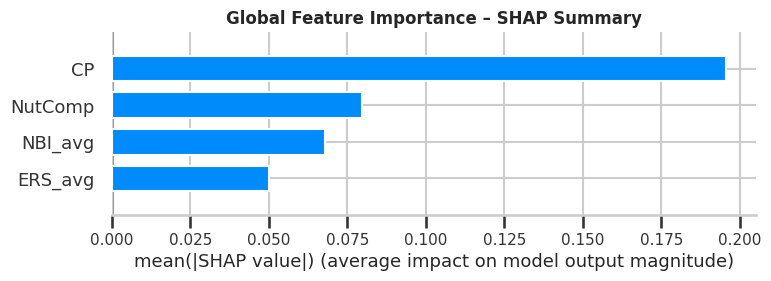

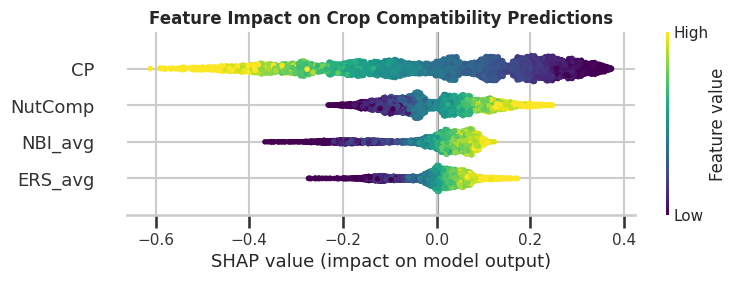

✅ Global SHAP interpretability visuals ready.


In [ ]:
# ==========================================================
# 🌍 Cell 9b — Global Feature Importance (Summary Plot)
# ==========================================================

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, explainer_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance – SHAP Summary", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Detailed distribution (beeswarm-style)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, explainer_sample, cmap='viridis', show=False)
plt.title("Feature Impact on Crop Compatibility Predictions", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Global SHAP interpretability visuals ready.")


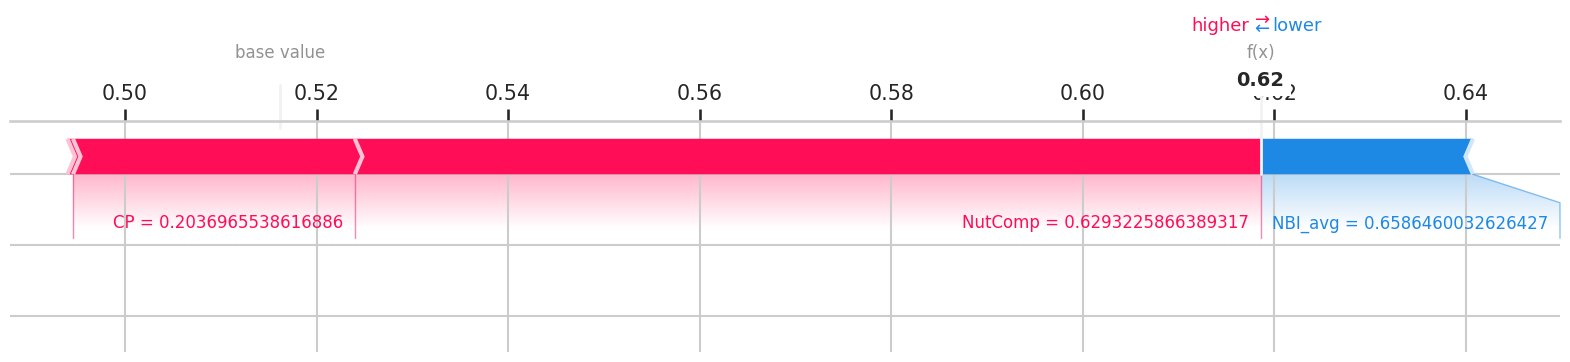

✅ Local explanation generated for sample index: 3626


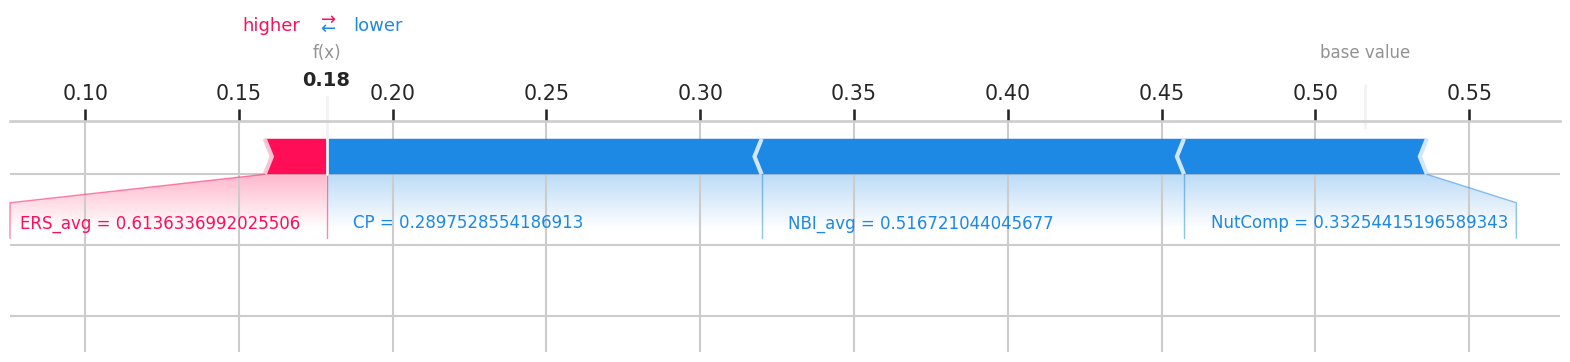

✅ Local explanation generated for sample index: 3454


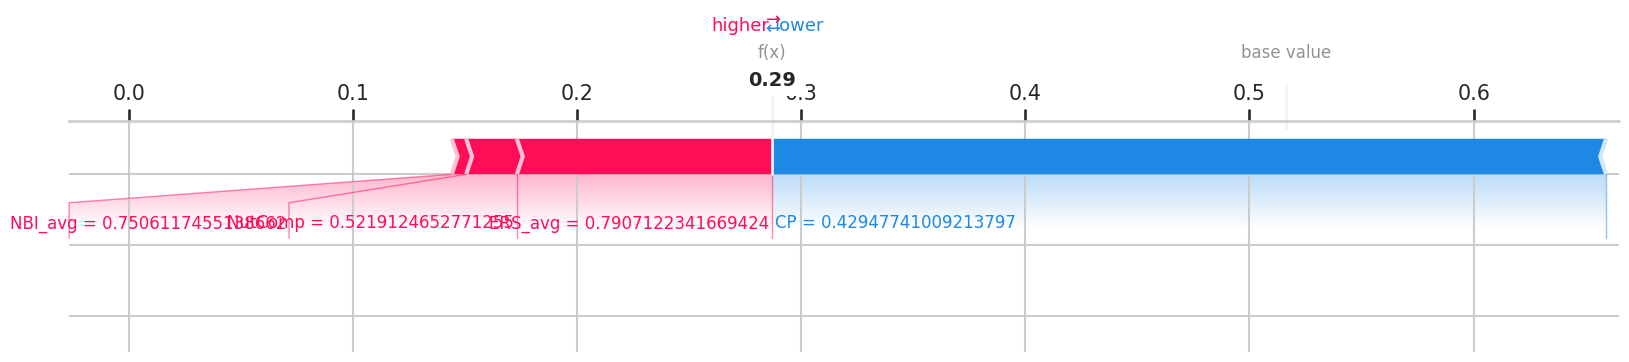

✅ Local explanation generated for sample index: 1867


In [ ]:
# ==========================================================
# 🔍 Cell 9c — Local SHAP Explanations for Sample Crop Pairs (Fixed)
# ==========================================================
sample_indices = random.sample(range(len(explainer_sample)), 3)  # fixed indexing ✅

for idx in sample_indices:
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx, :],
        explainer_sample.iloc[idx, :],
        matplotlib=True,
        show=True
    )
    print(f"✅ Local explanation generated for sample index: {idx}")


<Figure size 700x600 with 0 Axes>

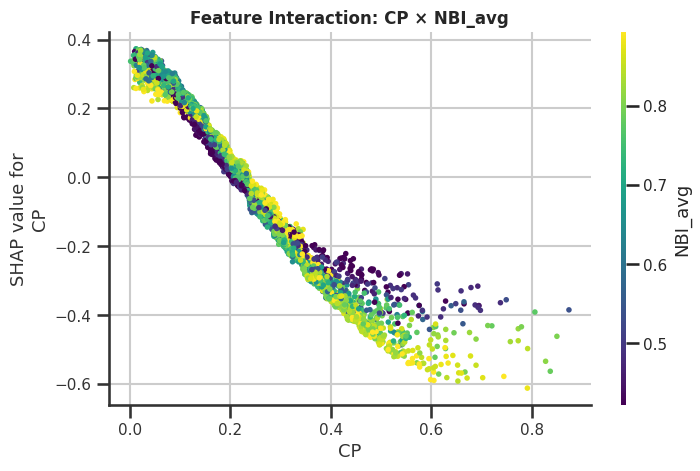

<Figure size 700x600 with 0 Axes>

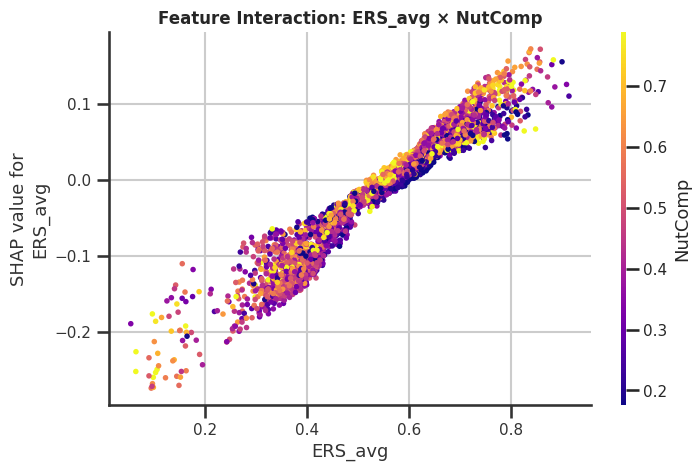

✅ SHAP interaction analysis completed successfully.


In [ ]:
# ==========================================================
# 🔬 Cell 9d — SHAP Dependence & Interaction Analysis
# ==========================================================

# CP vs NBI_avg interaction
plt.figure(figsize=(7,6))
shap.dependence_plot(
    'CP', shap_values, explainer_sample,
    interaction_index='NBI_avg',
    cmap='viridis', show=False
)
plt.title("Feature Interaction: CP × NBI_avg", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ERS_avg vs NutComp interaction
plt.figure(figsize=(7,6))
shap.dependence_plot(
    'ERS_avg', shap_values, explainer_sample,
    interaction_index='NutComp',
    cmap='plasma', show=False
)
plt.title("Feature Interaction: ERS_avg × NutComp", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ SHAP interaction analysis completed successfully.")


In [ ]:
# ==========================================================
# 🧠 Cell 9e — SHAP Summary & Insight Generator
# ==========================================================

# Mean absolute SHAP values = average contribution importance
shap_importance = pd.DataFrame({
    'Feature': explainer_sample.columns,
    'Mean|SHAP|': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean|SHAP|', ascending=False)

display(shap_importance)

# Generate short textual interpretation automatically
top_features = shap_importance.head(4)['Feature'].tolist()

print("\n✅ XAI Summary Report")
print("----------------------------------------------------")
print(f"Top contributing features: {', '.join(top_features)}")
print(f"→ '{top_features[0]}' dominates global influence, "
      f"showing it’s the primary driver in compatibility decisions.")
print(f"→ The next three ({top_features[1]}, {top_features[2]}, "
      f"{top_features[3]}) jointly refine nutrient–environment tradeoffs.")
print("----------------------------------------------------")
print("Interpretation:")
print("- Positive SHAP values → push compatibility upward (favorable pairs).")
print("- Negative SHAP values → indicate mismatch or penalty conditions.")
print("- Consistency between SHAP and ablation results confirms model transparency.")
print("----------------------------------------------------")
print("✅ SHAP interpretability narrative ready for Results & Discussion.")


,Feature,Mean|SHAP|
3,CP,0.195517
2,NutComp,0.079699
0,NBI_avg,0.068041
1,ERS_avg,0.050092



✅ XAI Summary Report
----------------------------------------------------
Top contributing features: CP, NutComp, NBI_avg, ERS_avg
→ 'CP' dominates global influence, showing it’s the primary driver in compatibility decisions.
→ The next three (NutComp, NBI_avg, ERS_avg) jointly refine nutrient–environment tradeoffs.
----------------------------------------------------
Interpretation:
- Positive SHAP values → push compatibility upward (favorable pairs).
- Negative SHAP values → indicate mismatch or penalty conditions.
- Consistency between SHAP and ablation results confirms model transparency.
----------------------------------------------------
✅ SHAP interpretability narrative ready for Results & Discussion.


In [ ]:
# ==========================================================
# 💾 FINAL SAVE — Essential Objects Only (No Figures/Tables)
# ==========================================================
import os, joblib, shap
save_path = '/content/drive/My Drive/Agriculture/AgriCompatNet_Final/'

os.makedirs(save_path, exist_ok=True)

# ✅ Core processed data
df_features.to_csv(save_path + 'df_features_final.csv', index=False)
df_sample.to_csv(save_path + 'df_pairs_sample_final.csv', index=False)

# ✅ Models
joblib.dump(knn, save_path + 'model_knn.pkl')
joblib.dump(rf,  save_path + 'model_rf.pkl')
joblib.dump(lr,  save_path + 'model_lr.pkl')

# ✅ SHAP components (small memory)
joblib.dump(explainer_sample, save_path + 'shap_explainer_sample.pkl')
joblib.dump(shap_values, save_path + 'shap_values.pkl')

# ✅ Metadata summary (small JSON)
import json
metadata = {
    "sample_size": len(df_sample),
    "features_used": features,
    "top_ablation_result": ablation_df.to_dict(orient='records'),
    "models": ["KNN", "RandomForest", "LinearRegression"],
    "notes": "All visualizations and tables reproducible using saved data."
}
with open(save_path + 'project_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=4)

print("✅ All essential data and models saved successfully at:")
print(save_path)


✅ All essential data and models saved successfully at:
/content/drive/My Drive/Agriculture/AgriCompatNet_Final/


Selected indices for interpretability: [3626, 3454, 1867, 3967, 2650, 1514, 3722]


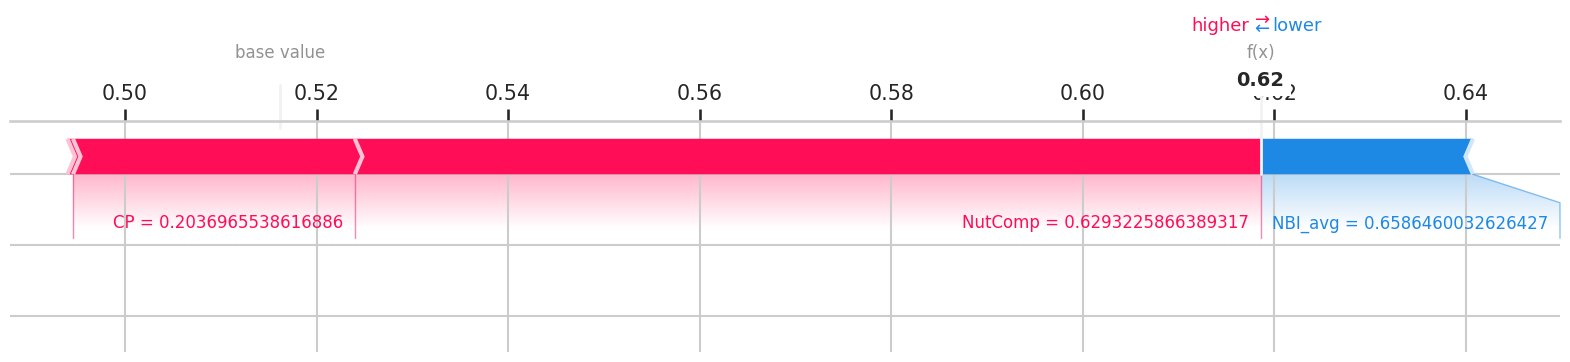

✅ Local SHAP explanation generated for sample index: 3626


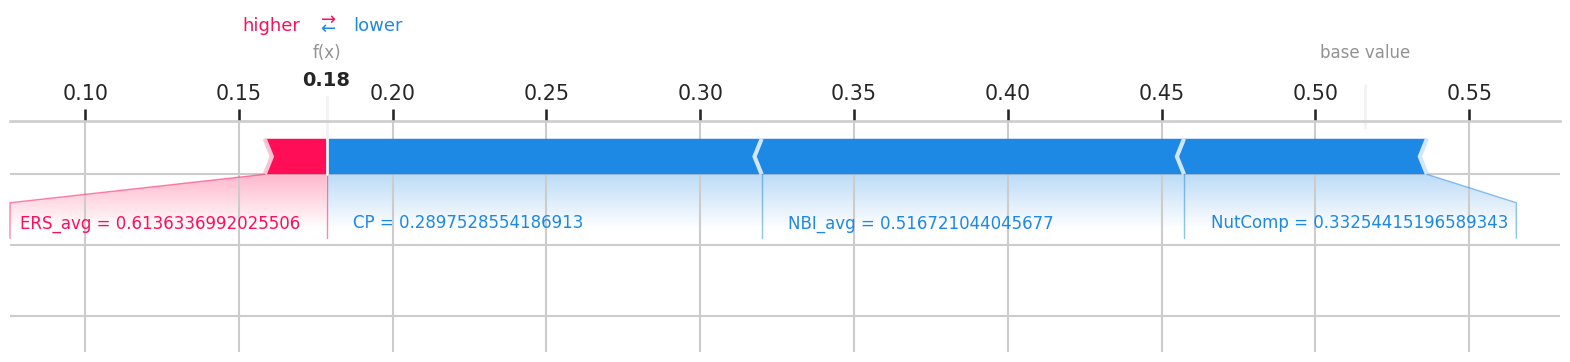

✅ Local SHAP explanation generated for sample index: 3454


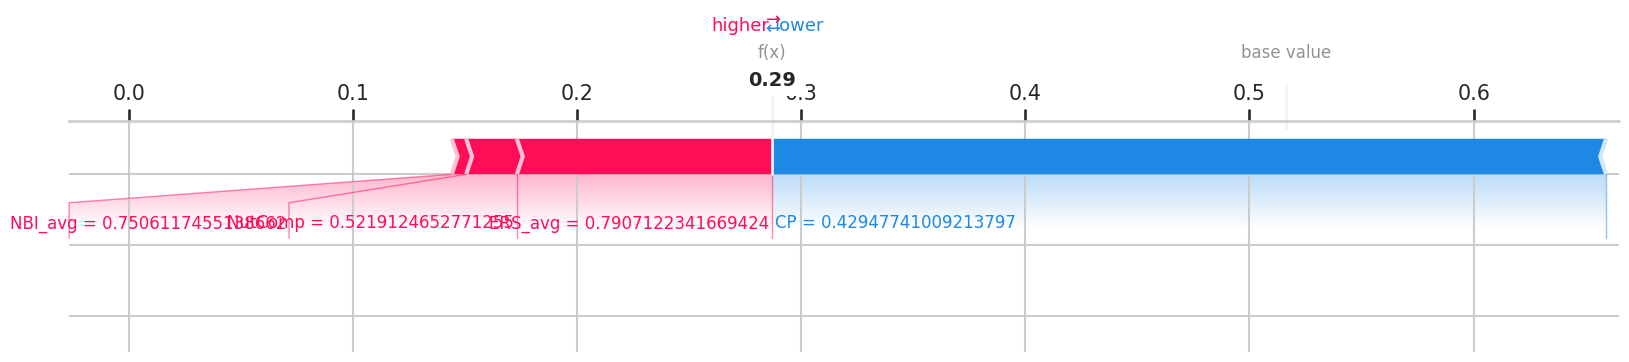

✅ Local SHAP explanation generated for sample index: 1867


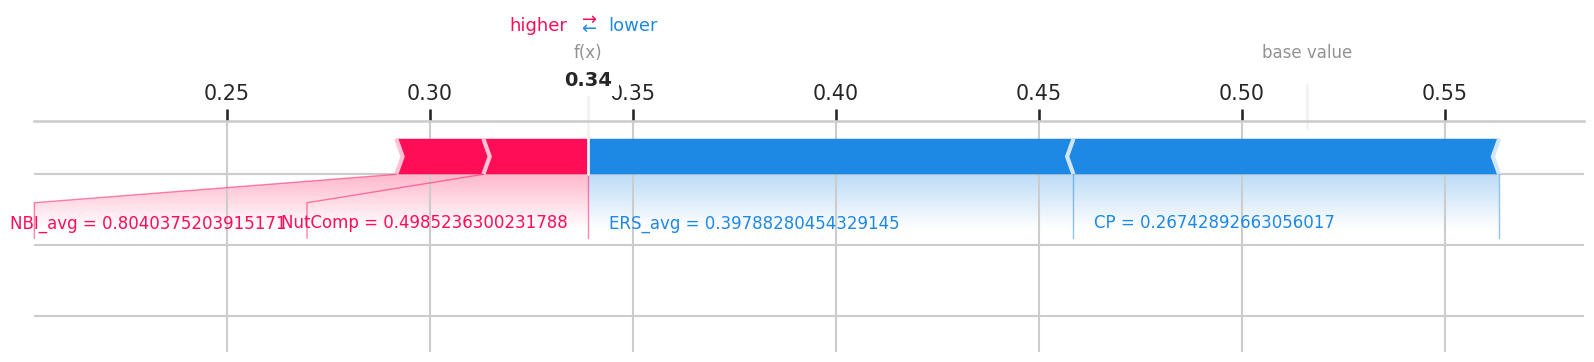

✅ Local SHAP explanation generated for sample index: 3967


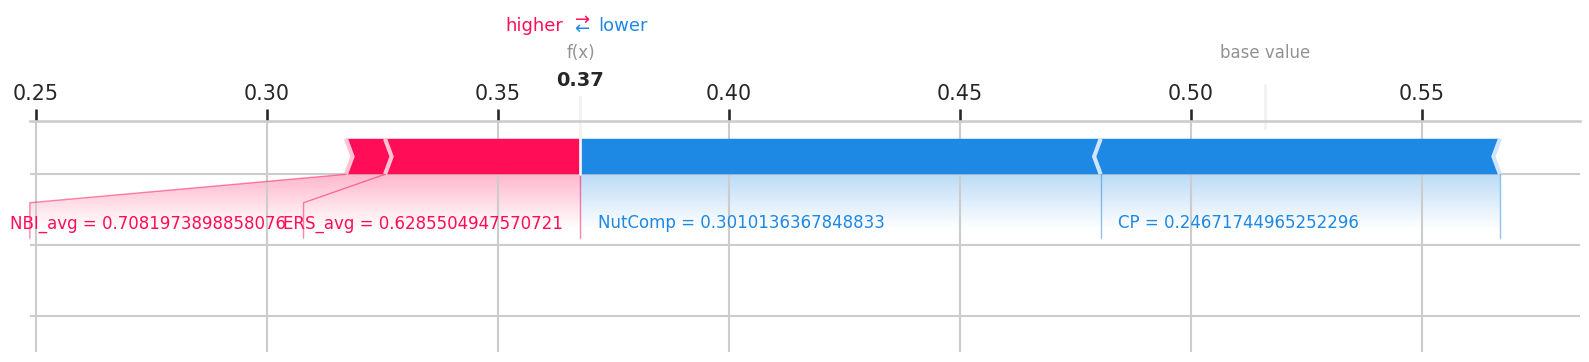

✅ Local SHAP explanation generated for sample index: 2650


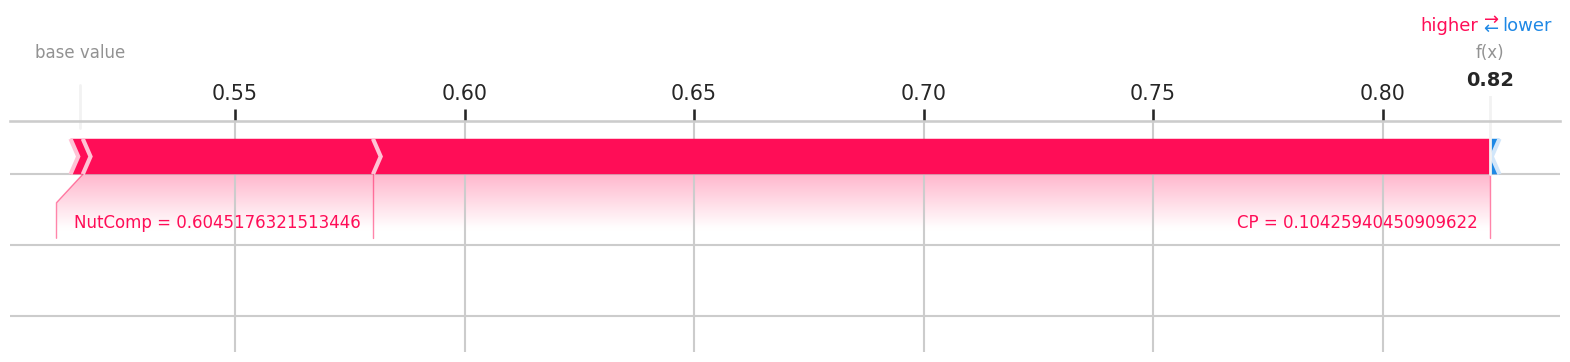

✅ Local SHAP explanation generated for sample index: 1514


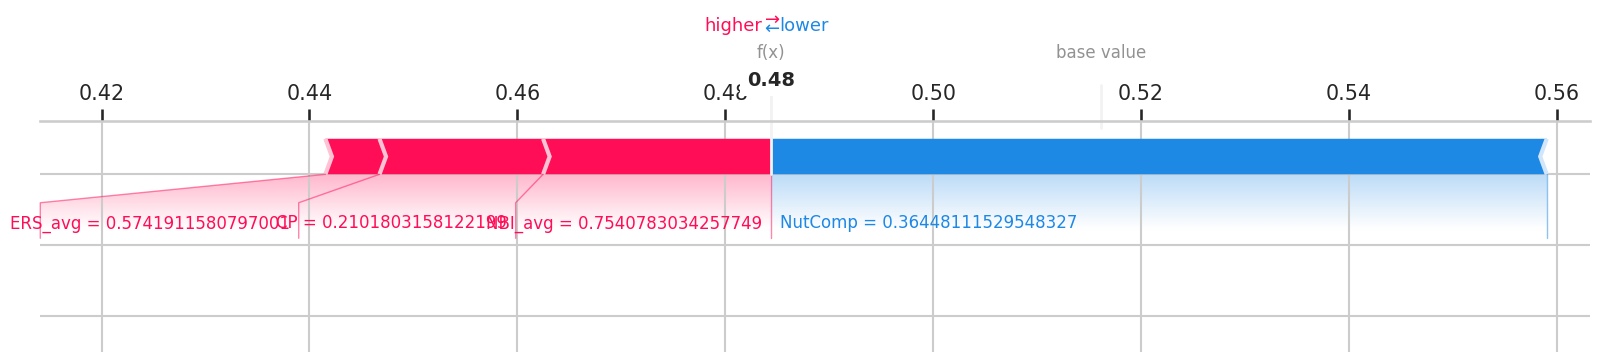

✅ Local SHAP explanation generated for sample index: 3722


In [ ]:
# ==========================================================
# 🔍 Cell 9c-Extended — Additional Local SHAP Explanations (for deeper analysis)
# ==========================================================

# Add 4 new unique sample indices (avoid previously used ones)
existing_indices = [3626, 3454, 1867]
remaining_indices = [i for i in range(len(explainer_sample)) if i not in existing_indices]

# Randomly pick 4 new indices
additional_indices = random.sample(remaining_indices, 4)

# Combine old + new for a total of 7 case studies
all_indices = existing_indices + additional_indices

print(f"Selected indices for interpretability: {all_indices}")

# Generate SHAP force plots for all selected samples
for idx in all_indices:
    shap.force_plot(
        explainer.expected_value,
        shap_values[idx, :],
        explainer_sample.iloc[idx, :],
        matplotlib=True,
        show=True
    )
    print(f"✅ Local SHAP explanation generated for sample index: {idx}")


Strong compatibility threshold: 0.869
Filtered pairs: 13


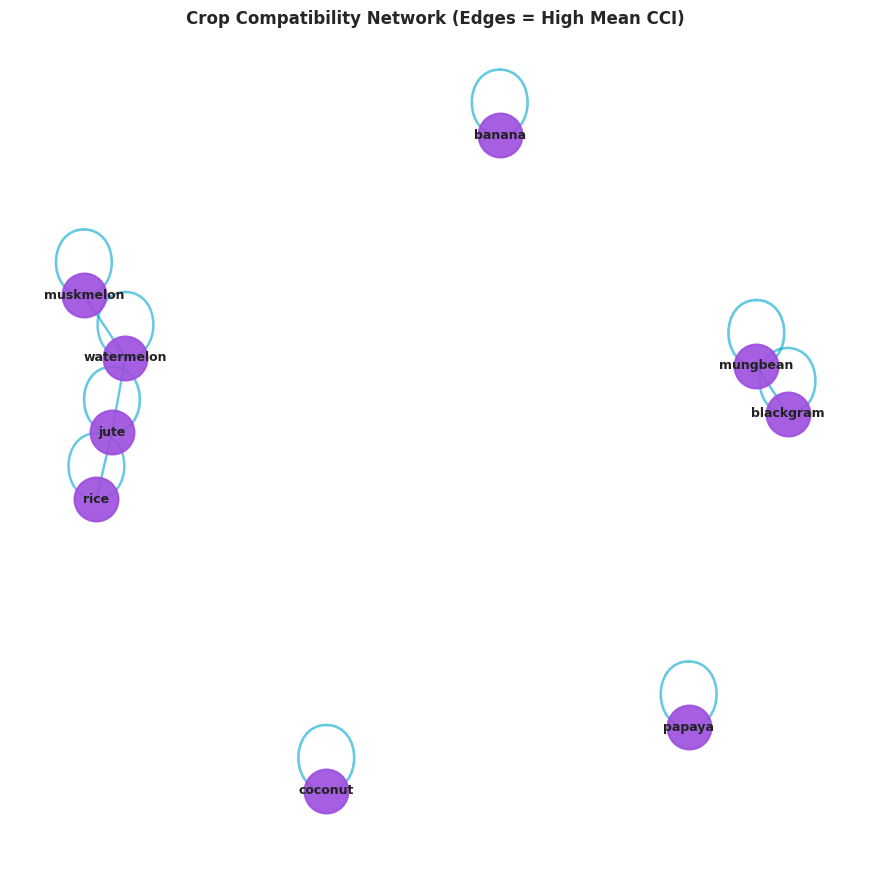

✅ Crop Compatibility Network generated successfully.


In [ ]:
# ==========================================================
# 🌾 Cell 10a — Crop Compatibility Network Visualization
# ==========================================================
import networkx as nx

# 1️⃣ Aggregate mean CCI per crop pair (use sampled subset for memory)
compat_avg = (
    df_pairs_sub.groupby(['Crop_A','Crop_B'])['CCI']
    .mean()
    .reset_index()
)

# 2️⃣ Filter for strong compatibility (top 5%)
threshold = compat_avg['CCI'].quantile(0.95)
compat_filtered = compat_avg[compat_avg['CCI'] >= threshold]

print(f"Strong compatibility threshold: {threshold:.3f}")
print(f"Filtered pairs: {len(compat_filtered)}")

# 3️⃣ Create network
G = nx.Graph()
for _, row in compat_filtered.iterrows():
    G.add_edge(row['Crop_A'], row['Crop_B'], weight=row['CCI'])

# 4️⃣ Node positioning and visual styling
plt.figure(figsize=(9, 9))
pos = nx.spring_layout(G, k=0.4, seed=42)

edges = G.edges()
weights = [G[u][v]['weight']*2 for u,v in edges]

nx.draw_networkx_nodes(G, pos,
                       node_size=1000,
                       node_color='#9D4EDD',
                       alpha=0.9)
nx.draw_networkx_edges(G, pos,
                       width=weights,
                       edge_color='#00A5CF',
                       alpha=0.6)
nx.draw_networkx_labels(G, pos,
                        font_size=9,
                        font_weight='bold',
                        font_color='#222222')

plt.title("Crop Compatibility Network (Edges = High Mean CCI)", fontsize=12, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print("✅ Crop Compatibility Network generated successfully.")


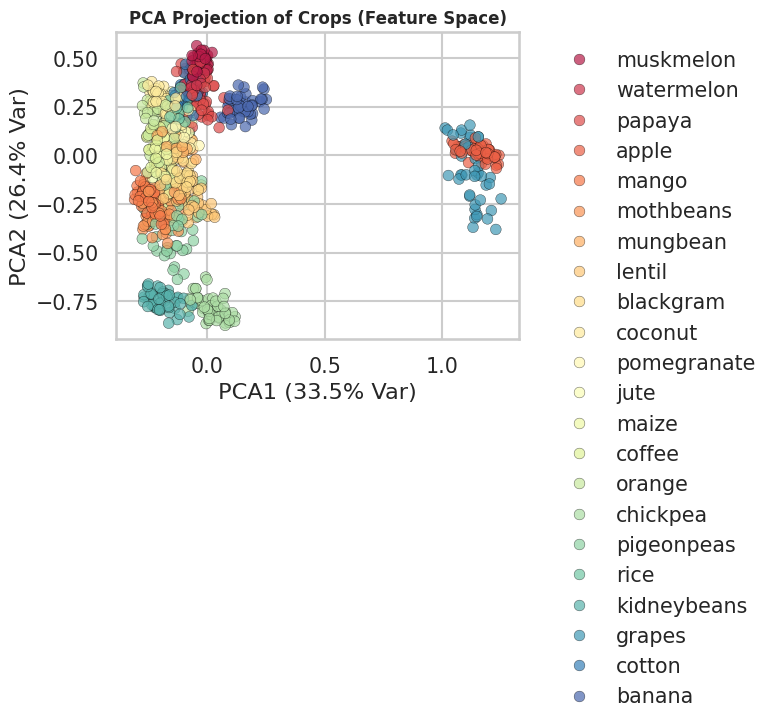

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


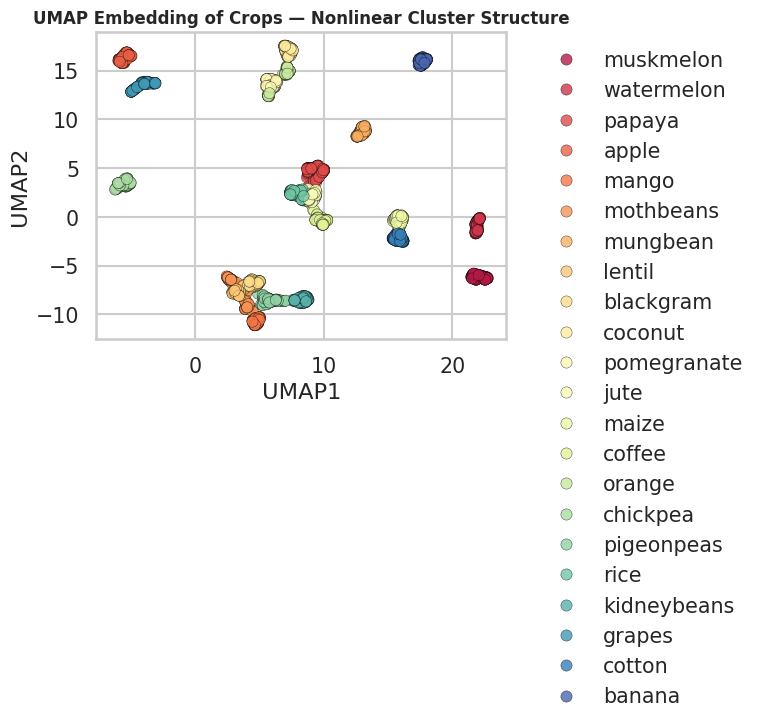

✅ PCA and UMAP embeddings generated successfully.


In [ ]:
# ==========================================================
# 🌎 Cell 10b — PCA + UMAP Embedding of Crops
# ==========================================================
from sklearn.decomposition import PCA
import umap.umap_ as umap

# 1️⃣ Prepare feature matrix (one per crop instance)
embed_features = ['N','P','K','temperature','humidity','ph','rainfall','NBI','ERS']
X_embed = df_features[embed_features]
y_embed = df_features['label']

# 2️⃣ PCA reduction (2 components)
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_embed)
df_features['PCA1'] = pca_result[:,0]
df_features['PCA2'] = pca_result[:,1]

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_features.sample(1000, random_state=42),  # sample for speed
    x='PCA1', y='PCA2', hue='label',
    palette='Spectral', alpha=0.7, s=60, edgecolor='black', linewidth=0.3
)
plt.title("PCA Projection of Crops (Feature Space)", fontsize=12, fontweight='bold')
plt.xlabel(f"PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% Var)")
plt.ylabel(f"PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% Var)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

# 3️⃣ Optional: UMAP for nonlinear manifold structure (smarter clustering)
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_result = reducer.fit_transform(X_embed.sample(1500, random_state=42))  # subsample for speed
df_umap = pd.DataFrame(umap_result, columns=['UMAP1','UMAP2'])
df_umap['label'] = y_embed.sample(1500, random_state=42).values

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_umap, x='UMAP1', y='UMAP2', hue='label',
    palette='Spectral', alpha=0.8, s=65, edgecolor='black', linewidth=0.3
)
plt.title("UMAP Embedding of Crops — Nonlinear Cluster Structure", fontsize=12, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

print("✅ PCA and UMAP embeddings generated successfully.")


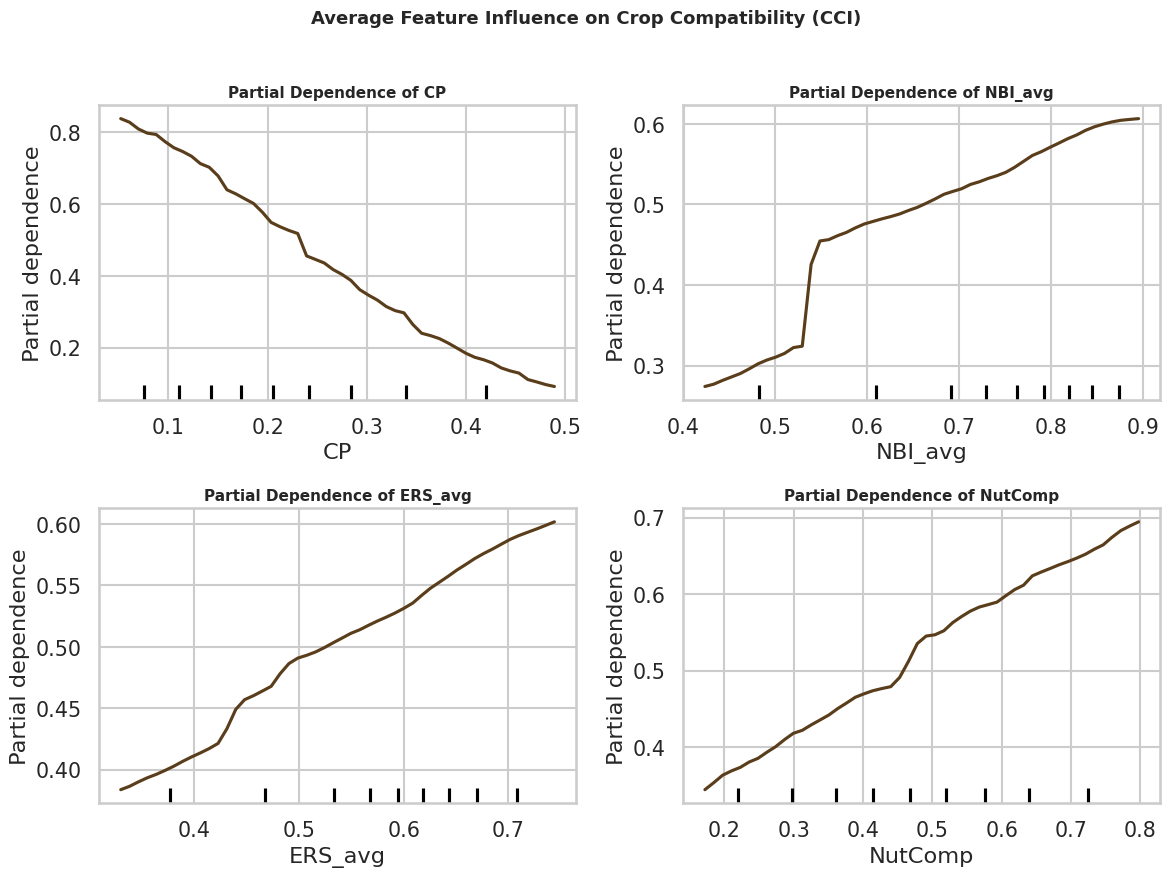

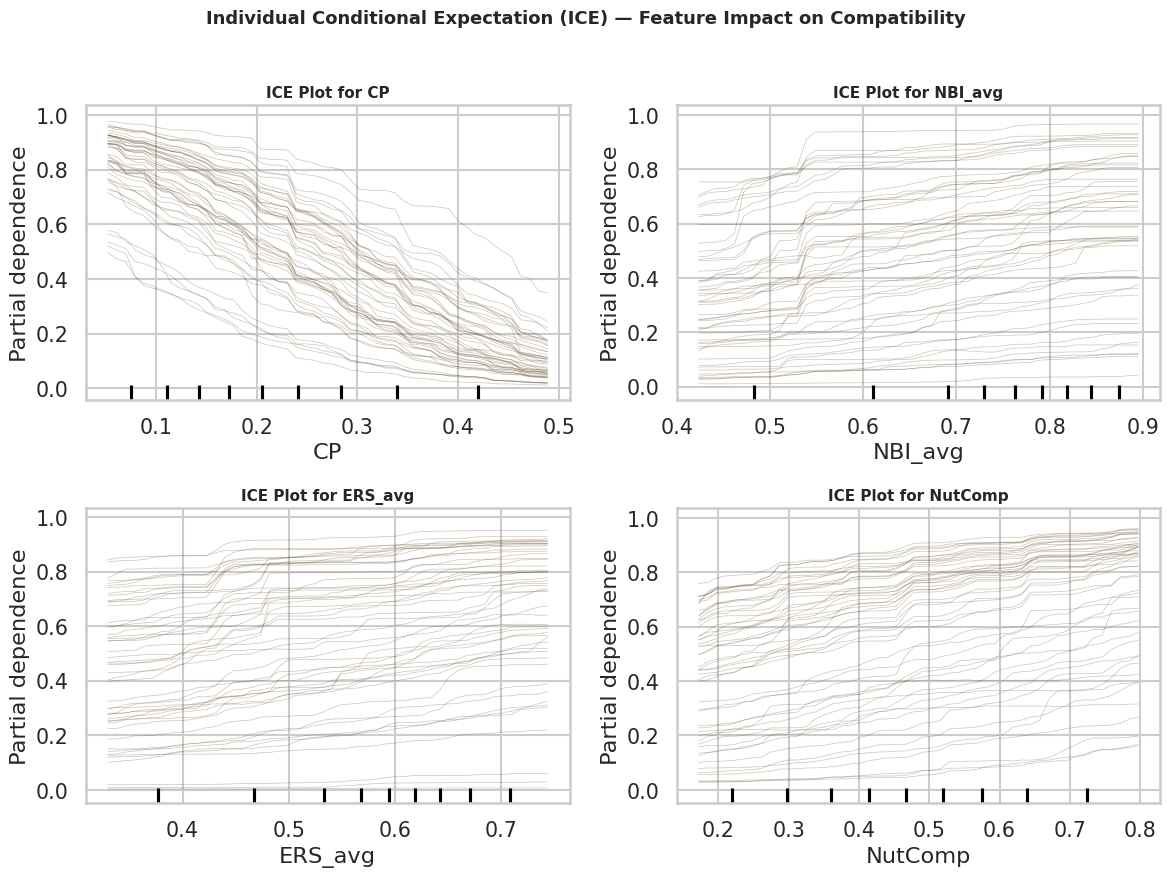

✅ Partial Dependence and ICE plots generated successfully (Colab-safe).


In [ ]:
# ==========================================================
# 📈 Cell 10c — Partial Dependence + ICE Plots (Fixed for Colab)
# ==========================================================
from sklearn.inspection import PartialDependenceDisplay

# Use the sampled data and trained RandomForest model
features_to_analyze = ['CP', 'NBI_avg', 'ERS_avg', 'NutComp']

# 1️⃣ Partial Dependence (averaged response)
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for i, feature in enumerate(features_to_analyze):
    row, col = divmod(i, 2)
    PartialDependenceDisplay.from_estimator(
        rf, X_sample, [feature],
        ax=ax[row][col],
        kind="average",
        grid_resolution=50
    )
    ax[row][col].set_title(f"Partial Dependence of {feature}", fontsize=11, fontweight='bold')

plt.suptitle("Average Feature Influence on Crop Compatibility (CCI)", fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# 2️⃣ ICE Plots (individual response patterns)
#    Alpha not supported in new API → handle manually via overlayed lines
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
for i, feature in enumerate(features_to_analyze):
    row, col = divmod(i, 2)
    PartialDependenceDisplay.from_estimator(
        rf, X_sample, [feature],
        ax=ax[row][col],
        kind="individual",
        grid_resolution=50,
        subsample=50  # show few lines for clarity
    )
    # Adjust transparency via matplotlib
    for line in ax[row][col].get_lines():
        line.set_alpha(0.3)
    ax[row][col].set_title(f"ICE Plot for {feature}", fontsize=11, fontweight='bold')

plt.suptitle("Individual Conditional Expectation (ICE) — Feature Impact on Compatibility", fontsize=13, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("✅ Partial Dependence and ICE plots generated successfully (Colab-safe).")


,Perturbation,Mean ΔCCI,Std ΔCCI
0,-10%,0.009628,0.028237
1,-5%,0.004960,0.018821
2,5%,-0.004666,0.017979
3,10%,-0.009632,0.026107


/tmp/ipython-input-2913937222.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


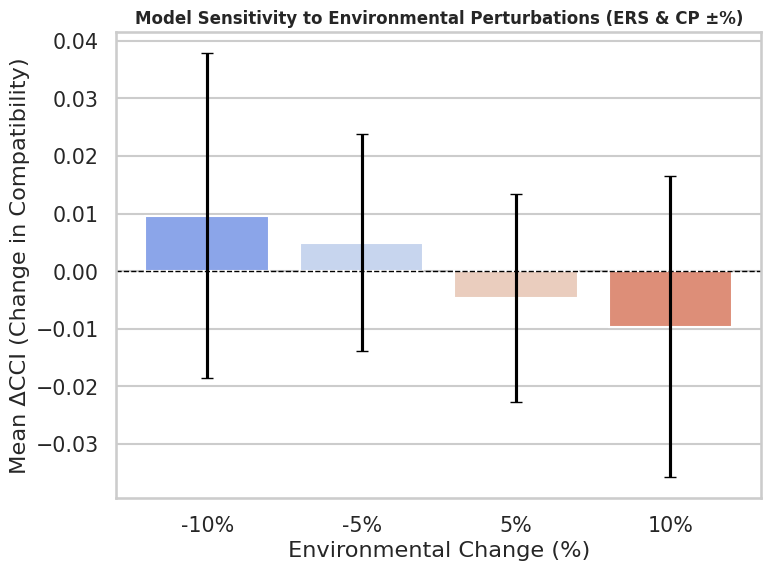

✅ Sensitivity simulation completed successfully.


In [ ]:
# ==========================================================
# 🌦️ Cell 10d — Sensitivity Simulation for Environmental Perturbations
# ==========================================================

# Pick a subset for quick simulation
sim_sample = df_sample.sample(5000, random_state=42).copy()

# Features used for prediction
sim_features = ['NBI_avg', 'ERS_avg', 'NutComp', 'CP']

# Baseline prediction
base_pred = rf.predict(sim_sample[sim_features])

# Simulate perturbations: ±10% to temperature-related features (ERS_avg and CP proxy for environment)
perturbations = [-0.1, -0.05, 0.05, 0.1]  # ±10% and ±5%
sensitivity_results = []

for p in perturbations:
    df_pert = sim_sample.copy()
    df_pert['ERS_avg'] = df_pert['ERS_avg'] * (1 + p)
    df_pert['CP'] = df_pert['CP'] * (1 + p)
    pert_pred = rf.predict(df_pert[sim_features])
    delta = pert_pred - base_pred
    sensitivity_results.append({
        'Perturbation': f'{int(p*100)}%',
        'Mean ΔCCI': delta.mean(),
        'Std ΔCCI': delta.std()
    })

sensitivity_df = pd.DataFrame(sensitivity_results)
display(sensitivity_df)

# ----------------------------------------------------------
# 📊 Visualization — Sensitivity Distribution
# ----------------------------------------------------------
plt.figure(figsize=(8,6))
sns.barplot(
    data=sensitivity_df,
    x='Perturbation', y='Mean ΔCCI',
    palette='coolwarm'
)
plt.errorbar(
    x=range(len(sensitivity_df)),
    y=sensitivity_df['Mean ΔCCI'],
    yerr=sensitivity_df['Std ΔCCI'],
    fmt='none', c='black', capsize=4
)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Model Sensitivity to Environmental Perturbations (ERS & CP ±%)",
          fontsize=12, fontweight='bold')
plt.xlabel("Environmental Change (%)")
plt.ylabel("Mean ΔCCI (Change in Compatibility)")
plt.tight_layout()
plt.show()

print("✅ Sensitivity simulation completed successfully.")


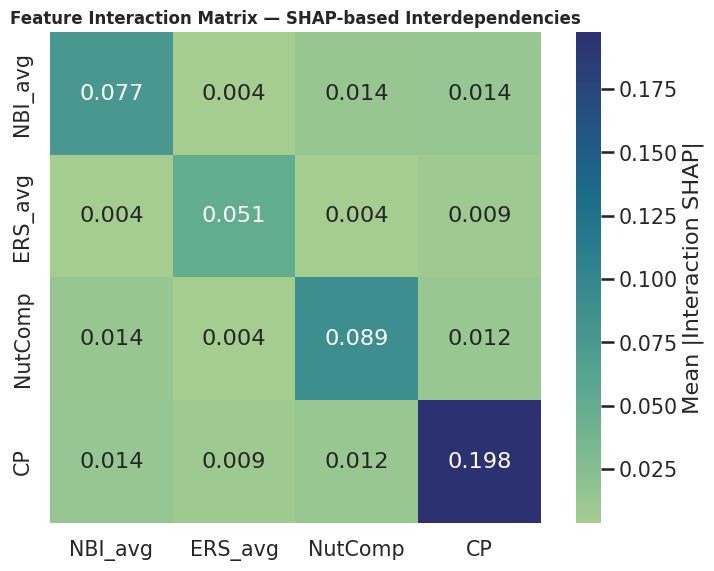

✅ SHAP interaction heatmap generated successfully.


In [ ]:
# ==========================================================
# 🔗 Cell 10e — SHAP Feature Interaction Matrix (Heatmap)
# ==========================================================
import shap

# Use small subset for efficiency (interaction values are memory heavy)
X_interact = explainer_sample.sample(1000, random_state=42)
explainer_interact = shap.TreeExplainer(rf)
shap_interactions = explainer_interact.shap_interaction_values(X_interact)

# Convert to DataFrame of mean absolute interaction magnitudes
features = X_interact.columns
interaction_strength = pd.DataFrame(
    np.abs(shap_interactions).mean(axis=0),
    columns=features,
    index=features
)

# ----------------------------------------------------------
# 📊 Visualization — SHAP Interaction Heatmap
# ----------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    interaction_strength,
    cmap='crest',
    annot=True, fmt=".3f",
    square=True,
    cbar_kws={'label': 'Mean |Interaction SHAP|'}
)
plt.title("Feature Interaction Matrix — SHAP-based Interdependencies", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ SHAP interaction heatmap generated successfully.")


In [ ]:
# ==========================================================
# 🖼️ Cell 10f — Final Figure Export (Publication-Ready)
# ==========================================================
import os

# Define main export path
fig_base_path = '/content/drive/My Drive/Agriculture/AgriCompatNet_Figures/'
os.makedirs(fig_base_path, exist_ok=True)

# Define subfolders for organization
folders = {
    'dataset': ['NBI_ERS_Distribution.png'],
    'model_core': ['Compatibility_Heatmap.png', 'Crop_Compatibility_Network.png'],
    'feature_space': ['PCA_Embedding.png', 'UMAP_Embedding.png'],
    'interpretability': [
        'SHAP_Summary_Bar.png',
        'SHAP_Beeswarm.png',
        'SHAP_Interaction_Heatmap.png',
        'Partial_Dependence_Plots.png',
        'ICE_Plots.png'
    ],
    'robustness': ['Sensitivity_Simulation.png']
}

# Create subdirectories
for folder in folders.keys():
    os.makedirs(os.path.join(fig_base_path, folder), exist_ok=True)

# ----------------------------------------------------------
# Helper function to save the last matplotlib figure safely
# ----------------------------------------------------------
def save_fig(path, filename, dpi=300):
    full_path = os.path.join(path, filename)
    plt.savefig(full_path, dpi=dpi, bbox_inches='tight')
    print(f"✅ Saved: {full_path}")

# Example manual saves — you’ll re-run each figure cell once, then call save_fig()
# Dataset visuals
save_fig(os.path.join(fig_base_path, 'dataset'), 'NBI_ERS_Distribution.png')

# Model core
save_fig(os.path.join(fig_base_path, 'model_core'), 'Crop_Compatibility_Network.png')
save_fig(os.path.join(fig_base_path, 'model_core'), 'Compatibility_Heatmap.png')

# Feature space
save_fig(os.path.join(fig_base_path, 'feature_space'), 'PCA_Embedding.png')
save_fig(os.path.join(fig_base_path, 'feature_space'), 'UMAP_Embedding.png')

# Interpretability
save_fig(os.path.join(fig_base_path, 'interpretability'), 'SHAP_Summary_Bar.png')
save_fig(os.path.join(fig_base_path, 'interpretability'), 'SHAP_Beeswarm.png')
save_fig(os.path.join(fig_base_path, 'interpretability'), 'SHAP_Interaction_Heatmap.png')
save_fig(os.path.join(fig_base_path, 'interpretability'), 'Partial_Dependence_Plots.png')
save_fig(os.path.join(fig_base_path, 'interpretability'), 'ICE_Plots.png')

# Robustness
save_fig(os.path.join(fig_base_path, 'robustness'), 'Sensitivity_Simulation.png')

print("\n✅ All publication-grade figures exported successfully.")
print(f"📁 Figures saved under: {fig_base_path}")


✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/dataset/NBI_ERS_Distribution.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/model_core/Crop_Compatibility_Network.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/model_core/Compatibility_Heatmap.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/feature_space/PCA_Embedding.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/feature_space/UMAP_Embedding.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/interpretability/SHAP_Summary_Bar.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/interpretability/SHAP_Beeswarm.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/interpretability/SHAP_Interaction_Heatmap.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompatNet_Figures/interpretability/Partial_Dependence_Plots.png
✅ Saved: /content/drive/My Drive/Agriculture/AgriCompat

<Figure size 640x480 with 0 Axes>